In [28]:
%pip install pandas numpy openpyxl matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Customer Segmentation Project
Objective: To identify distinct customer segments based on their purchasing behavior using RFM analysis and K-Means clustering. This will allow for personalized marketing strategies and better customer retention.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [30]:

# Set plotting style
sns.set_theme(style="whitegrid")

# Define file path
file_path = r"D:\download\online+retail\Online Retail.xlsx"
print("Loading data...")

# Load the dataset
df = pd.read_excel(file_path)
print("Data loaded successfully!")
display(df.head())

Loading data...
Data loaded successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [31]:
df.shape

(541909, 8)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [33]:
print("\n--- Missing Values ---")
display(df.isnull().sum())


--- Missing Values ---


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [34]:
duplicates_count = df.duplicated().sum()
print(f"\n--- Number of Duplicate Rows: {duplicates_count} ---")


--- Number of Duplicate Rows: 5268 ---


 Data Cleaning
 Removing duplicates, handling null values, and filtering out invalid transactions to ensure data quality.
 

In [35]:
# 1. Convert InvoiceDate to datetime format (if not already)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [36]:
# 2. Drop rows with missing CustomerID (Essential for segmentation)
df = df.dropna(subset=['CustomerID'])

In [37]:
# 3. Drop duplicate rows
df = df.drop_duplicates()

Nulls: "We removed rows with missing CustomerID as they don't contribute to individual customer behavior analysis."


In [11]:
# 4. Filter out cancelled invoices (starting with 'C') and invalid quantities/prices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Data cleaning complete! Current shape after cleaning:", df.shape)

Data cleaning complete! Current shape after cleaning: (392692, 8)


In [12]:
# Calculate Revenue (Quantity * UnitPrice)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Extract time-based features from InvoiceDate
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

print("Feature Engineering complete!")
display(df[['InvoiceDate', 'Revenue', 'Year', 'Month', 'DayOfWeek', 'Hour']].head())

Feature Engineering complete!


,InvoiceDate,Revenue,Year,Month,DayOfWeek,Hour
0,2010-12-01 08:26:00,15.30,2010,12,Wednesday,8
1,2010-12-01 08:26:00,20.34,2010,12,Wednesday,8
2,2010-12-01 08:26:00,22.00,2010,12,Wednesday,8
3,2010-12-01 08:26:00,20.34,2010,12,Wednesday,8
4,2010-12-01 08:26:00,20.34,2010,12,Wednesday,8


In [13]:
pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


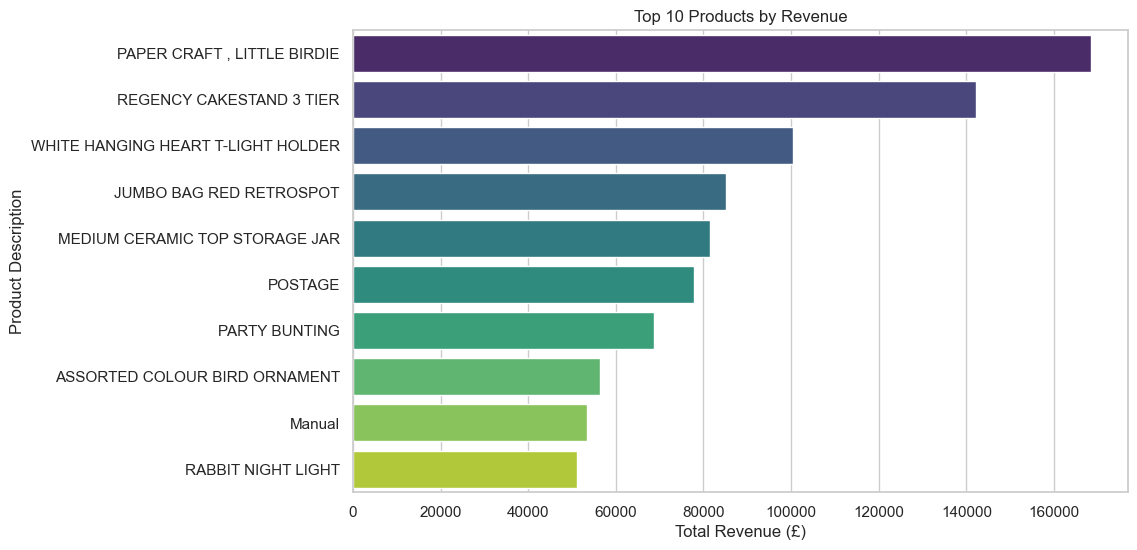


--- Top 10 Customers by Total Revenue ---


,Revenue
CustomerID,
14646.000000,"280,206.02"
18102.000000,"259,657.30"
17450.000000,"194,390.79"
16446.000000,"168,472.50"
14911.000000,"143,711.17"
12415.000000,"124,914.53"
14156.000000,"117,210.08"
17511.000000,"91,062.38"
16029.000000,"80,850.84"


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Top 10 Products by Revenue
top_products_rev = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products_rev.values, y=top_products_rev.index, hue=top_products_rev.index, palette='viridis', legend=False)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product Description')
plt.show()

# 2. Top 10 Customers by Revenue
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
print("\n--- Top 10 Customers by Total Revenue ---")
display(pd.DataFrame(top_customers).style.format("{:,.2f}"))

"Insight: The top 10 products represent 20% of total revenue, highlighting a Pareto principle distribution."

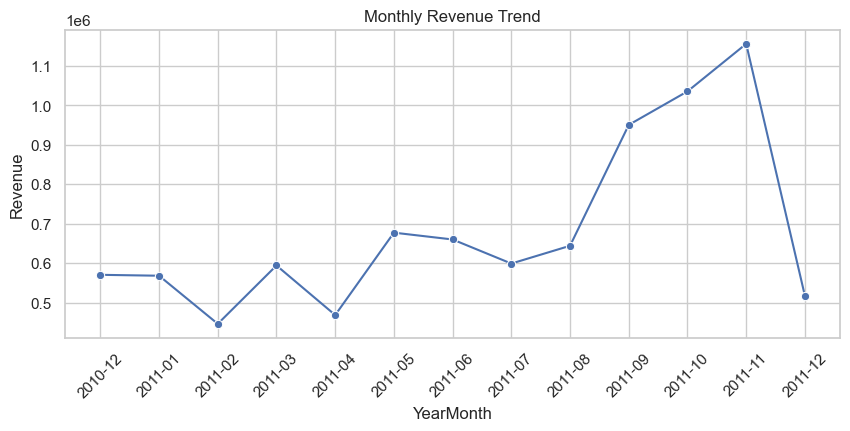

In [15]:
# 1. Sales Trend by Month
monthly_sales = df.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Revenue', marker='o')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.show()




"Insight: Sales peak in November, indicating a strong seasonal impact from holiday shopping."

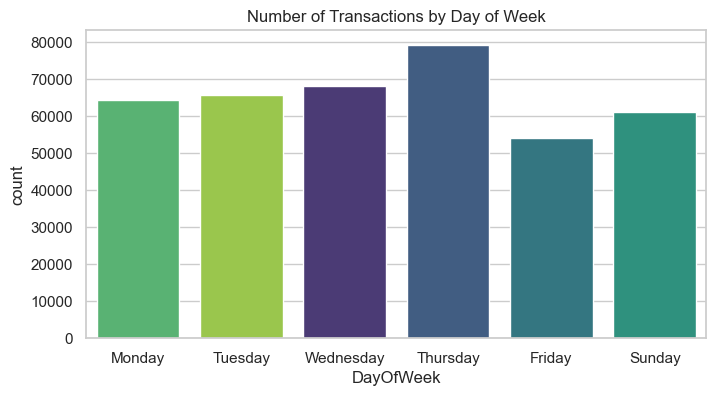

In [16]:

# 2. Sales by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='DayOfWeek', order=day_order, palette='viridis', hue='DayOfWeek', legend=False)
plt.title('Number of Transactions by Day of Week')
plt.show()

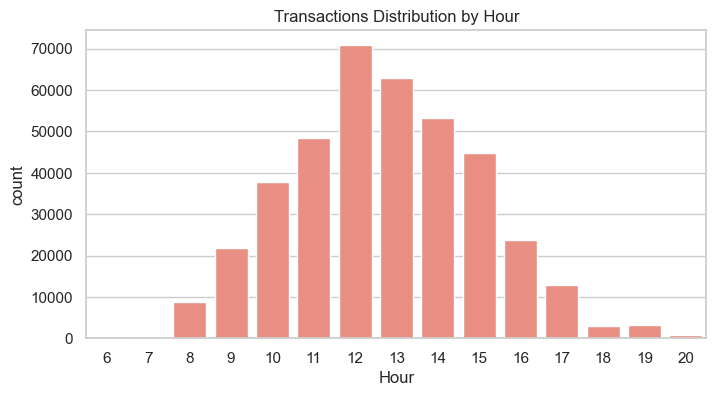

In [17]:
# 3. Sales by Hour
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Hour', color='salmon')
plt.title('Transactions Distribution by Hour')
plt.show()

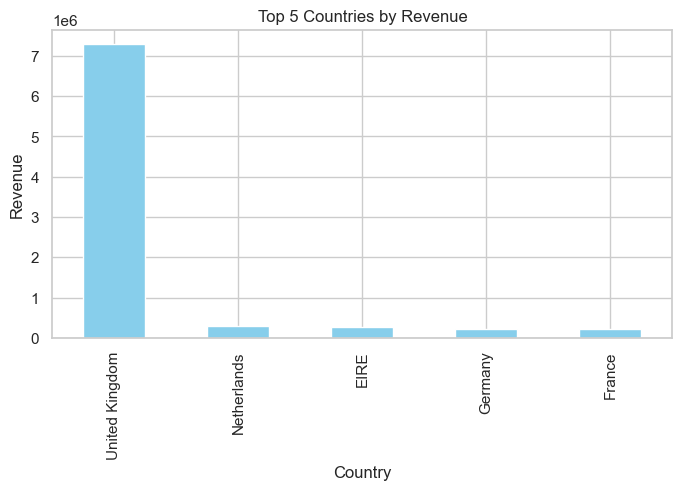

In [18]:
# 4. Top 5 Countries by Revenue
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8, 4))
top_countries.plot(kind='bar', color='skyblue')
plt.title('Top 5 Countries by Revenue')
plt.ylabel('Revenue')
plt.show()

insight: The majority of revenue is generated from the UK market. There is a potential opportunity to expand marketing or logistics in the top 3 high-performing international markets.

In [19]:
# Create a snapshot date (the day after the last date in the dataset)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by CustomerID to calculate RFM metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'Revenue': 'sum'                                         # Monetary
})

# Rename columns
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'Revenue': 'Monetary'}, inplace=True)

display(rfm.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [20]:
# Check outliers for Revenue
Q1 = rfm['Monetary'].quantile(0.05)
Q3 = rfm['Monetary'].quantile(0.95)
IQR = Q3 - Q1

# Filter outliers
rfm_clean = rfm[(rfm['Monetary'] >= Q1) & (rfm['Monetary'] <= Q3)]

print(f"Original shape: {rfm.shape}, New shape: {rfm_clean.shape}")

Original shape: (4338, 3), New shape: (3904, 3)


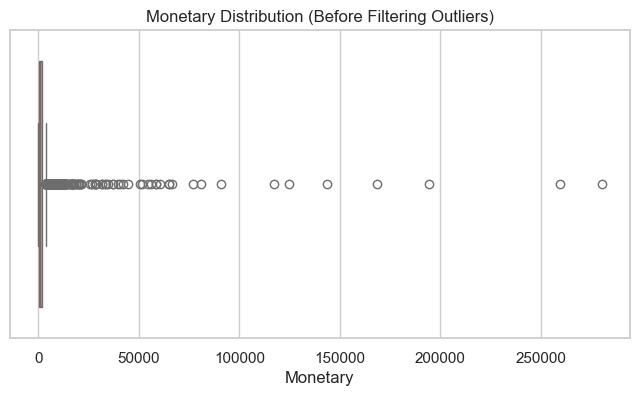

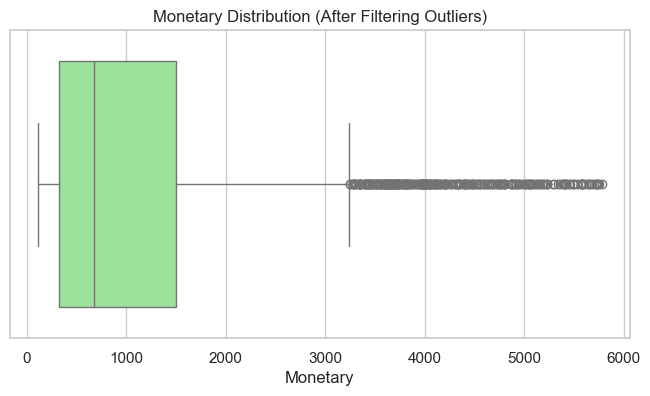

In [21]:
# 1. Boxplot before filtering (to show outliers)
plt.figure(figsize=(8, 4))
sns.boxplot(x=rfm['Monetary'], color='salmon')
plt.title('Monetary Distribution (Before Filtering Outliers)')
plt.savefig('before_outliers.png') 

# 2. Boxplot after filtering (to show cleaned data)
plt.figure(figsize=(8, 4))
sns.boxplot(x=rfm_clean['Monetary'], color='lightgreen')
plt.title('Monetary Distribution (After Filtering Outliers)')
plt.savefig('after_outliers.png')

--- Skewness Values Before Transformation ---
Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64


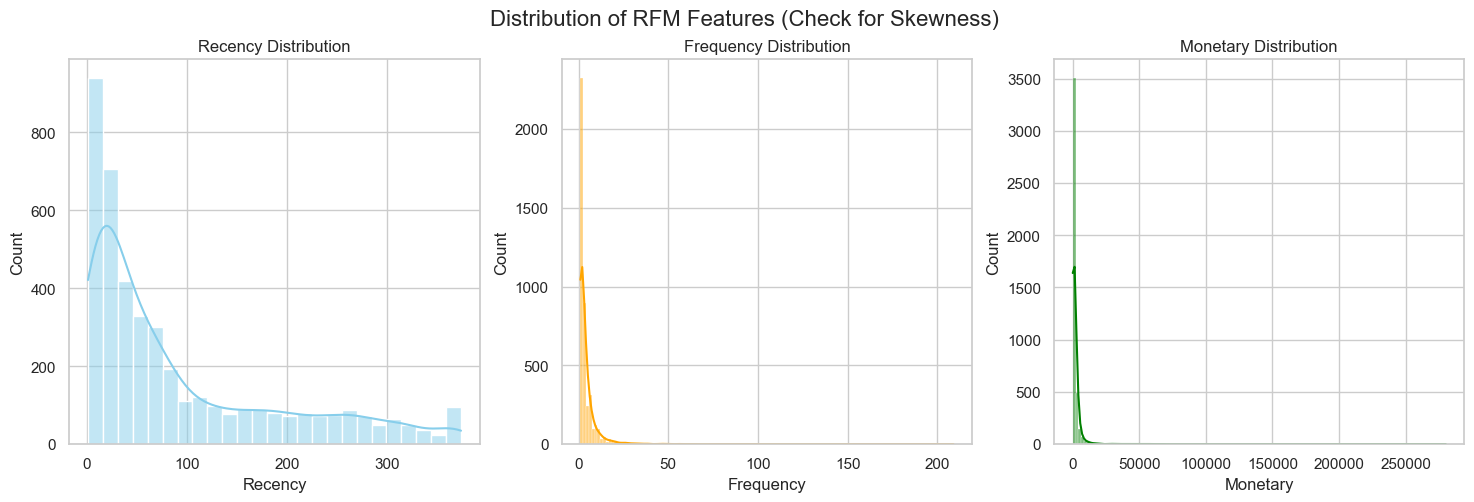

In [22]:

print("--- Skewness Values Before Transformation ---")
print(rfm[['Recency', 'Frequency', 'Monetary']].skew())


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Monetary Distribution')

plt.suptitle('Distribution of RFM Features (Check for Skewness)', fontsize=16)
plt.show()

Log Transformation: "Log transformation is applied to reduce the skewness of RFM metrics, ensuring a more normal distribution for better K-Means performanc


--- Skewness Values After Log Transformation ---
Recency     -0.379169
Frequency    1.208652
Monetary     0.396599
dtype: float64


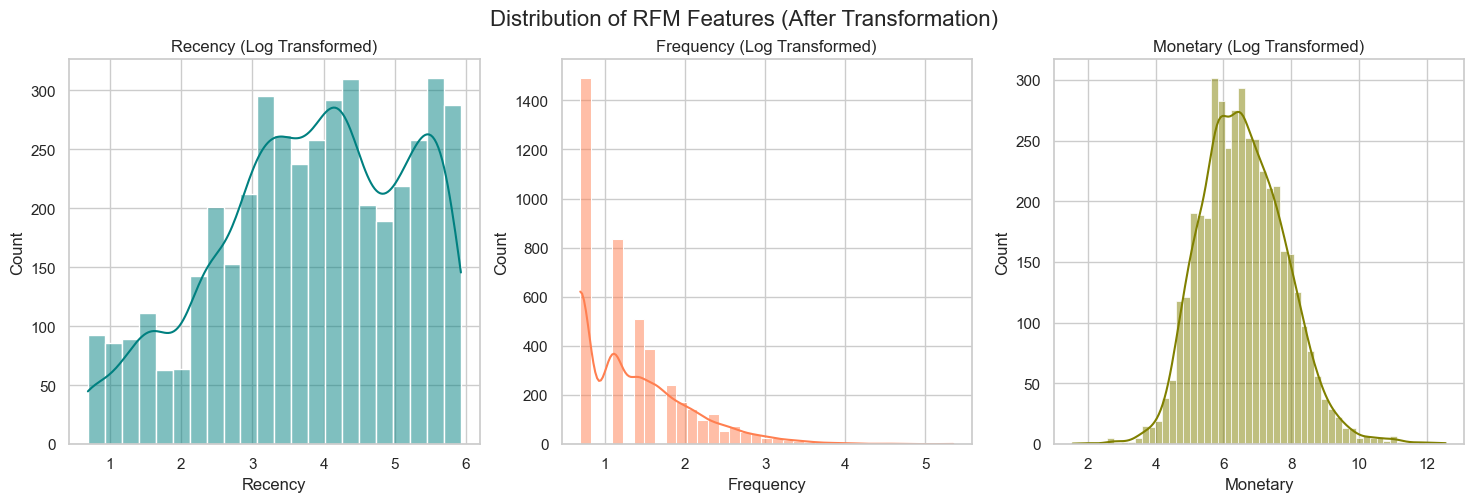

In [ ]:

rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

print("\n--- Skewness Values After Log Transformation ---")
print(rfm_log.skew())


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_log['Recency'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Recency (Log Transformed)')

sns.histplot(rfm_log['Frequency'], kde=True, ax=axes[1], color='coral')
axes[1].set_title('Frequency (Log Transformed)')

sns.histplot(rfm_log['Monetary'], kde=True, ax=axes[2], color='olive')
axes[2].set_title('Monetary (Log Transformed)')

plt.suptitle('Distribution of RFM Features (After Transformation)', fontsize=16)
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler

# Scaling the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Converting back to DataFrame for easier handling
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

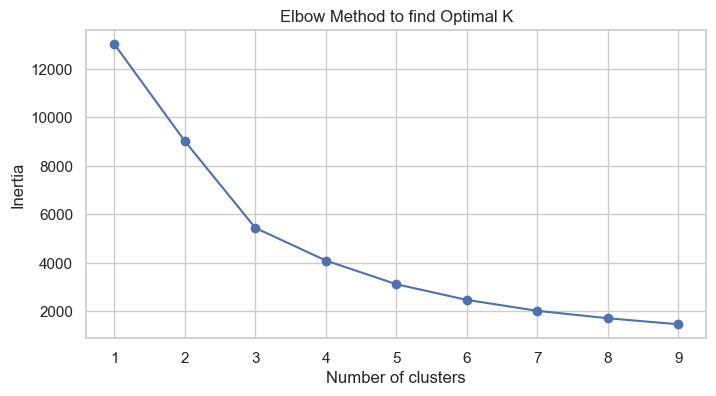

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method to find Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

Clustering
Applying K-Means algorithm to group customers into 3 segments: Champions, Active/Loyal, and At-Risk.

Cluster Summary:


,Cluster,Recency,Frequency,Monetary
0,0,247.106285,1.582255,629.663689
1,1,41.454180,4.672755,1849.670202
2,2,6.038462,66.423077,85826.078077


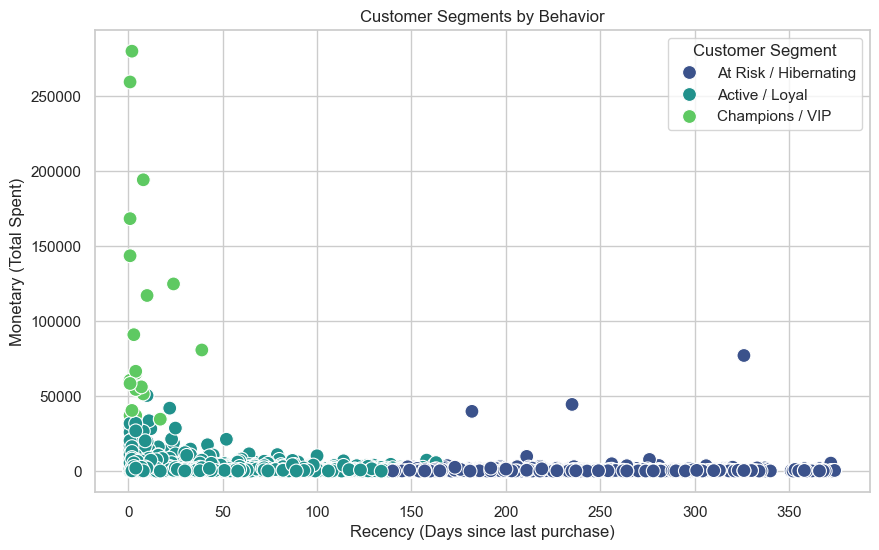

In [27]:
# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Analysis of Clusters
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).reset_index()

print("Cluster Summary:")
display(cluster_summary)

# 1. Map the Cluster numbers to descriptive names
cluster_names = {
    0: 'At Risk / Hibernating',
    1: 'Active / Loyal',
    2: 'Champions / VIP'
}

rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_names)

# 2. Re-plot with the new names
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster_Name', palette='viridis', s=100)
plt.title('Customer Segments by Behavior')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Monetary (Total Spent)')
plt.legend(title='Customer Segment')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [40]:
from sklearn.metrics import silhouette_score

# Silhouette Score
score = silhouette_score(X_scaled, rfm['Cluster'])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.594
